# 02 — STL Decomposition (Exploratory)

**Purpose.** Use Seasonal-Trend decomposition (STL) to *visually* separate each Tet-sensitive
category's weekly Google Trends series into three layers — **trend**, **seasonal**, and
**residual** — so we can see the repeating annual Tet shape isolated from long-run drift and
one-off shocks.

> ## Scope of this notebook — exploration only
>
> **STL here is a qualitative / visual tool. No official metric is derived from it.**
> Every quantified figure in this project (Tet uplift %, peak timing, holiday dip %) stays in
> `01_eda.ipynb`, computed by within-year baseline comparison. Those metrics are
> **scale-invariant under per-file 0-100 normalization** (see `docs/methodology.md` §4.6);
> STL is **not**. STL operates across all six per-file-normalized years at once, which breaks
> the "stay inside one file" guarantee that makes the baseline metrics valid. We therefore read
> the STL panels for *shape and story*, never for numbers. See the caveats cell for the full
> reasoning (year-boundary artifact, lunar-calendar drift).

**Categories.** Only the three categories with a confirmed Tet effect — `banh_keo`
(confectionery), `bia` (beer), `nuoc_ngot` (soft drinks). `dau_an` and `sua` showed **no Tet
spike** in `01_eda.ipynb`, so a Tet-focused decomposition adds little for them.

**Inputs:** `../data/processed/trends_long.csv` produced by `src/load_data.py`.

**Proxy caveat.** Every observation is a **search-implied** pattern, not a sales pattern
(see `docs/methodology.md` §5).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from pathlib import Path

pd.set_option('display.float_format', '{:.1f}'.format)

In [2]:
ROOT = Path('..').resolve()

df = pd.read_csv(ROOT / 'data' / 'processed' / 'trends_long.csv')
df['week_start'] = pd.to_datetime(df['week_start'])

# Same year-boundary dedup as 01_eda: each yearly Trends export shares one boundary
# week with its neighbour at a different per-file normalization. Keep the row whose
# file-year matches the calendar year of week_start. See docs/methodology.md §4.6.
df = df[df['week_start'].dt.year == df['year']].copy()

# Gregorian date of Mung 1 Tet (Lunar Jan 1) for each year in scope.
tet_dates = {
    2020: pd.Timestamp('2020-01-25'),
    2021: pd.Timestamp('2021-02-12'),
    2022: pd.Timestamp('2022-02-01'),
    2023: pd.Timestamp('2023-01-22'),
    2024: pd.Timestamp('2024-02-10'),
    2025: pd.Timestamp('2025-01-29'),
}

KEYWORDS = ['banh_keo', 'bia', 'nuoc_ngot']  # Tet-sensitive categories only
LABELS = {
    'banh_keo':  'Banh keo (Confectionery)',
    'bia':       'Bia (Beer)',
    'nuoc_ngot': 'Nuoc ngot (Soft drinks)',
}

# STL needs a gap-free, evenly-spaced series. Confirm every category is a clean
# run of consecutive Sundays (7-day steps) with no missing weeks before we fit.
for kw in KEYWORDS:
    g = df[df['keyword'] == kw].sort_values('week_start')
    gaps = g['week_start'].diff().dropna().dt.days.unique()
    assert set(gaps) == {7}, f'{kw}: non-weekly gaps {sorted(gaps)}'
    assert g['search_index'].isna().sum() == 0, f'{kw}: has NaNs'
    print(f'{kw:10s} {len(g):3d} weeks  {g.week_start.min().date()} -> {g.week_start.max().date()}  OK')

banh_keo   313 weeks  2020-01-05 -> 2025-12-28  OK
bia        313 weeks  2020-01-05 -> 2025-12-28  OK
nuoc_ngot  313 weeks  2020-01-05 -> 2025-12-28  OK


## STL setup and parameter choices

STL splits an **additive** series into `observed = trend + seasonal + residual`.

- **Additive (not multiplicative) is the right model here.** Because every year's CSV is
  normalized independently to 0-100, the Tet peak sits near 100 in *every* year regardless of
  real volume — so the seasonal swing has roughly constant amplitude year to year. That is
  exactly the additive assumption. (A multiplicative model would need a log transform and is
  meant for amplitude that grows with level — not our case.)
- **`period=52`** — weekly data with an annual cycle. We have ~313 weeks ~ 6 cycles, comfortably
  above STL's two-cycle minimum.
- **`robust=True`** — down-weights outlier weeks when estimating trend and seasonal, so one-off
  shocks (COVID weeks, a single viral spike) are pushed **into the residual** instead of bending
  the trend or distorting the seasonal template. For an exploration whose whole point is to *see*
  the anomalies in the residual, robust fitting is what we want.

In [3]:
def run_stl(keyword):
    """Fit a robust annual STL to one keyword's weekly series."""
    g = df[df['keyword'] == keyword].sort_values('week_start')
    series = pd.Series(
        g['search_index'].values,
        index=pd.DatetimeIndex(g['week_start'], freq='W-SUN'),
    )
    return STL(series, period=52, robust=True).fit()

results = {kw: run_stl(kw) for kw in KEYWORDS}

# Quick sanity read: trend endpoints + seasonal amplitude per category.
for kw, res in results.items():
    amp = res.seasonal.max() - res.seasonal.min()
    print(f'{kw:10s} trend {res.trend.iloc[0]:5.1f} -> {res.trend.iloc[-1]:5.1f}'
          f'   seasonal amplitude ~{amp:.0f}   resid std {res.resid.std():.1f}')

banh_keo   trend  52.7 ->  43.4   seasonal amplitude ~75   resid std 9.4
bia        trend  46.7 ->  46.6   seasonal amplitude ~67   resid std 8.5
nuoc_ngot  trend  72.1 ->  71.8   seasonal amplitude ~63   resid std 10.3


## Reading the four-panel decomposition

Each category gets one figure with four stacked panels sharing the same time axis. Dashed red
lines mark Mung 1 Tet every year.

1. **Observed** — the raw weekly series (what `01_eda` plotted).
2. **Trend** — the slow multi-year drift. **Not real demand growth.** Under per-file
   normalization this line mostly reflects how *peaked* each year is relative to its own
   baseline, not whether real search volume rose or fell. Shown for completeness; do not read a
   demand trend off it.
3. **Seasonal** — the repeating annual template. **This is the main payoff:** the Tet bump
   isolated from everything else, shown to recur every year with a stable shape.
4. **Residual** — what trend + seasonal cannot explain. Read carefully (next section): near Tet
   it is dominated by a *calendar artifact*; away from Tet it surfaces *genuine* secondary
   events.

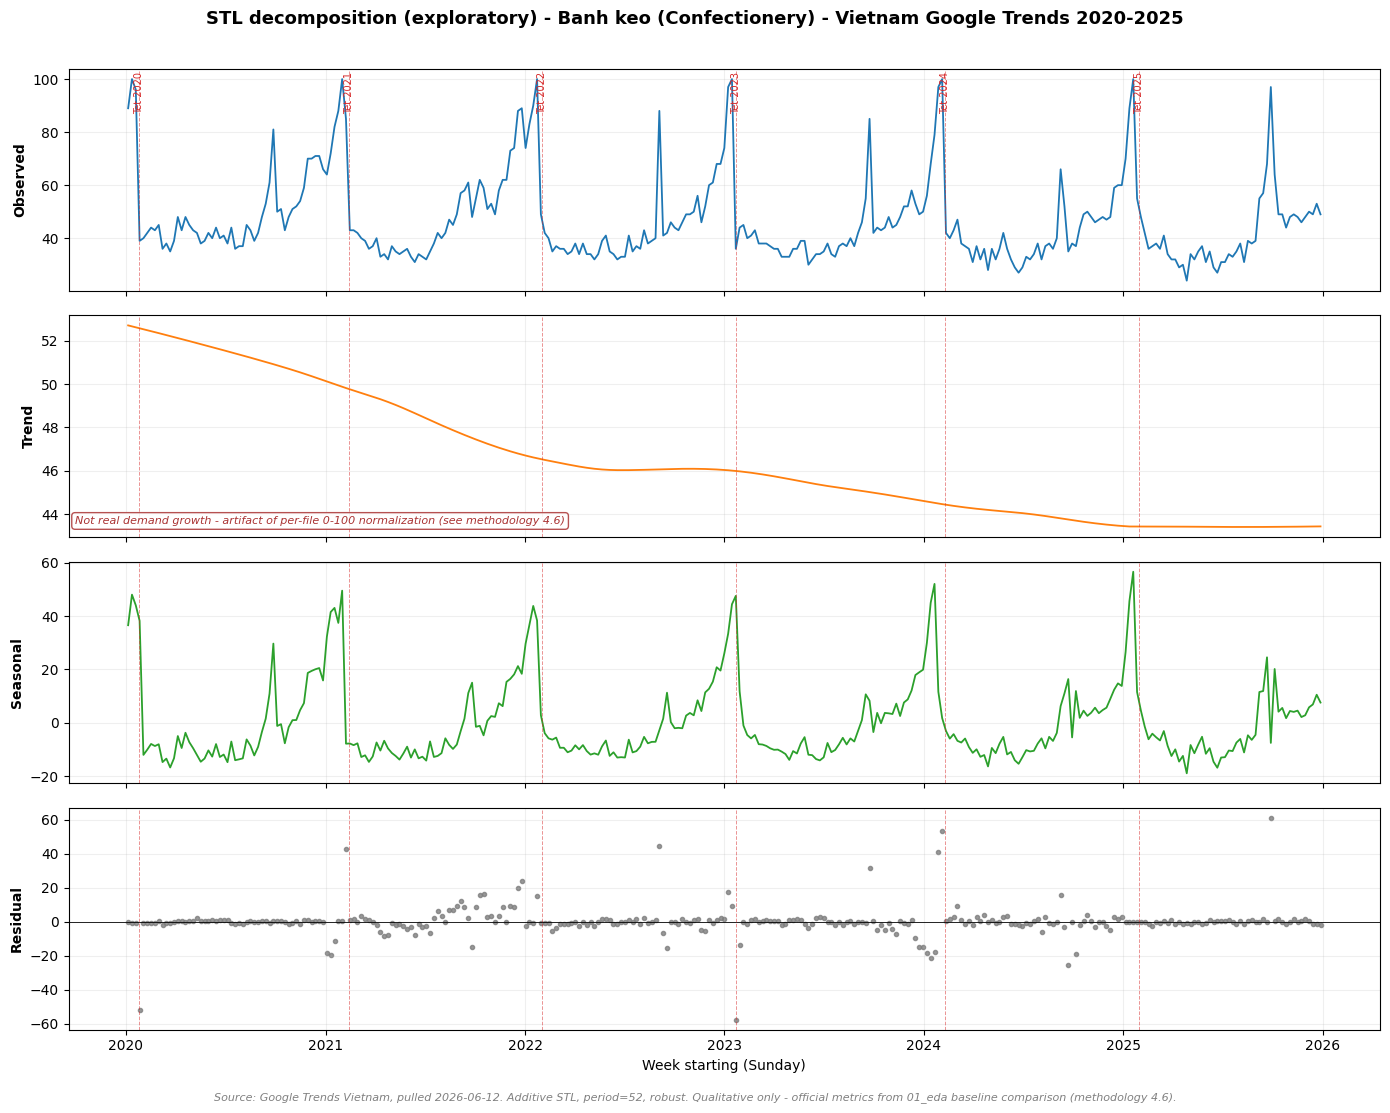

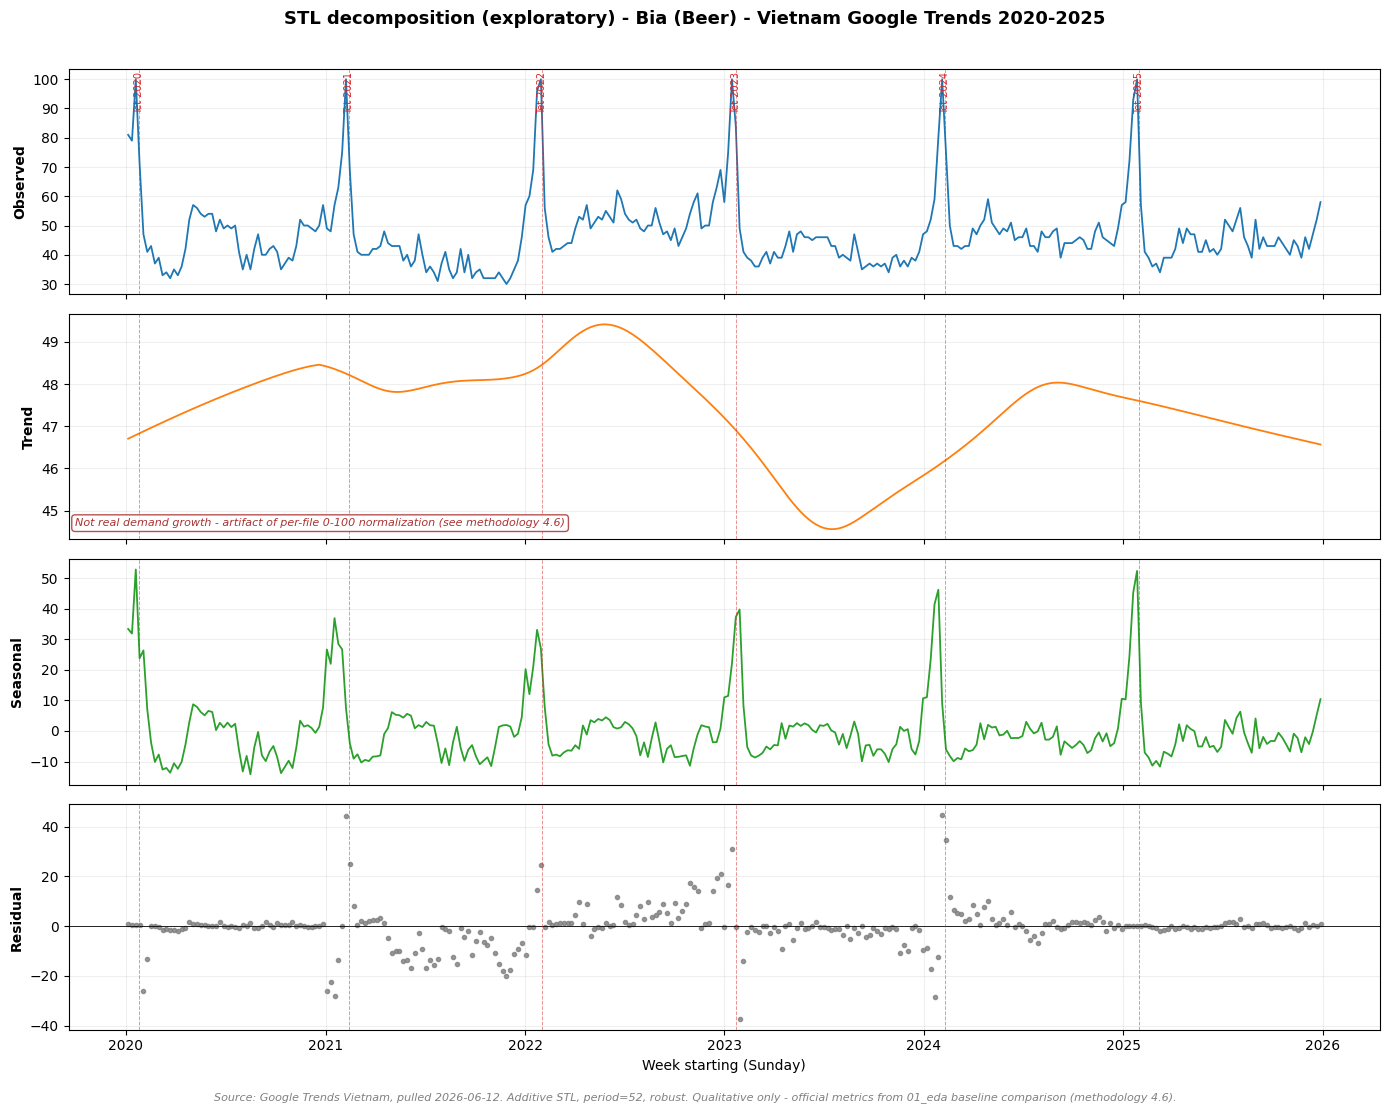

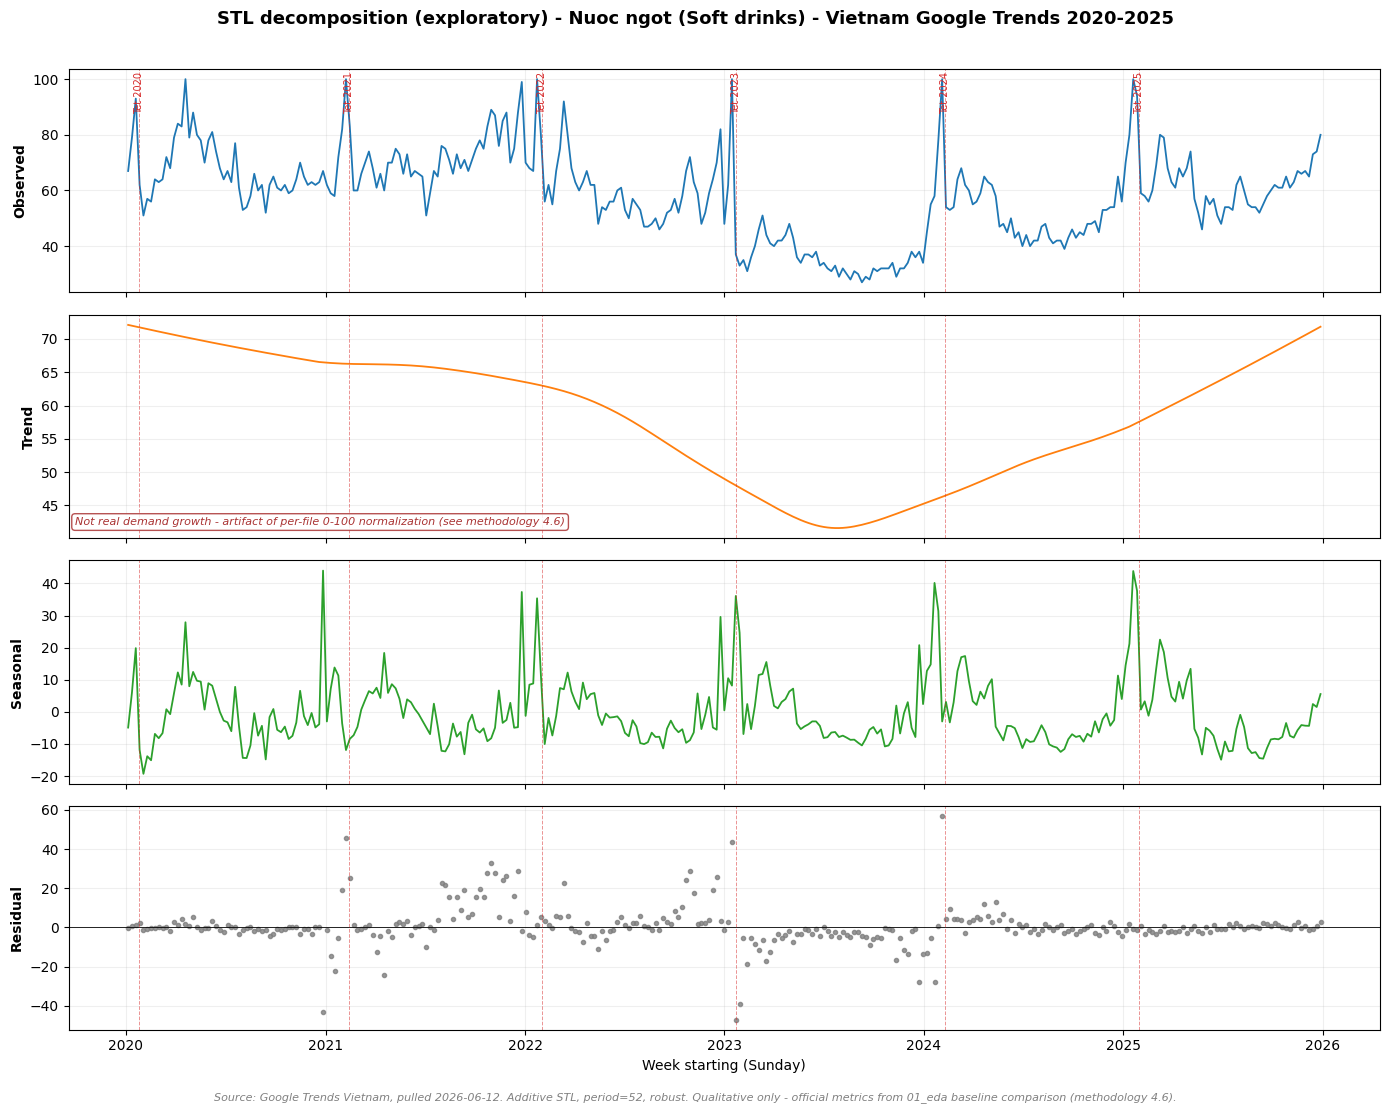

In [4]:
def plot_decomposition(keyword, res, save_dir):
    label = LABELS[keyword]
    panels = [
        ('Observed', res.observed, '#1f77b4', False),
        ('Trend',    res.trend,    '#ff7f0e', False),
        ('Seasonal', res.seasonal, '#2ca02c', False),
        ('Residual', res.resid,    '#7f7f7f', True),
    ]
    fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

    for ax, (name, series, color, is_resid) in zip(axes, panels):
        if is_resid:
            ax.axhline(0, color='black', linewidth=0.6)
            ax.scatter(series.index, series.values, s=9, color=color, alpha=0.8)
        else:
            ax.plot(series.index, series.values, color=color, linewidth=1.3)

        for year, t in tet_dates.items():
            ax.axvline(t, color='#d62728', linestyle='--', linewidth=0.7, alpha=0.5)

        ax.set_ylabel(name, fontsize=10, fontweight='bold')
        ax.grid(True, alpha=0.2)

    # Caveat tag on the trend panel so the artifact warning travels with the figure.
    axes[1].text(
        0.005, 0.05,
        'Not real demand growth - artifact of per-file 0-100 normalization (see methodology 4.6)',
        transform=axes[1].transAxes, fontsize=8, style='italic', color='#aa3333',
        va='bottom', ha='left',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#aa3333', alpha=0.85),
    )

    # Tet-year labels along the top panel.
    top = axes[0].get_ylim()[1]
    for year, t in tet_dates.items():
        axes[0].text(t, top * 0.99, f'Tet {year}', rotation=90,
                     fontsize=7, ha='center', va='top', color='#d62728')

    axes[-1].set_xlabel('Week starting (Sunday)', fontsize=10)
    fig.suptitle(
        f'STL decomposition (exploratory) - {label} - Vietnam Google Trends 2020-2025',
        fontsize=13, fontweight='bold', y=0.995,
    )
    fig.text(
        0.5, 0.004,
        'Source: Google Trends Vietnam, pulled 2026-06-12. Additive STL, period=52, robust. '
        'Qualitative only - official metrics from 01_eda baseline comparison (methodology 4.6).',
        ha='center', fontsize=8, style='italic', color='gray',
    )
    plt.tight_layout(rect=[0, 0.015, 1, 0.985])

    save_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_dir / f'02_stl_{keyword}.png', dpi=120, bbox_inches='tight')
    plt.show()


fig_dir = ROOT / 'notebooks' / 'figures'
for kw in KEYWORDS:
    plot_decomposition(kw, results[kw], fig_dir)

## Residual anomalies — artifact vs genuine signal

The residual panel is the most interesting and the most easily *mis*read. Two very different
things live in it:

**(A) Near-Tet residuals are mostly a lunar-calendar artifact — not COVID.**
Mung 1 drifts up to three weeks across the Gregorian calendar (22 Jan in 2023 -> 12 Feb in 2021).
A `period=52` seasonal template is anchored to the *week of the year*, so it cannot track a
holiday that moves. When the real Tet lands earlier or later than the template's average peak,
the difference dumps into the residual. The tell: the **largest** near-Tet residuals fall in
**2023 and 2024 — the two non-COVID years with the most extreme early/late Tet dates** — not in
the COVID years. So we explicitly **do not** read the residual as a clean COVID detector.

**(B) Residuals far from Tet surface genuine secondary events.**
Away from the moving-holiday confound, large residuals are interpretable. The table below splits
every notable residual (|z| > 2.5) into near-Tet (+/-3 weeks, treat as artifact) vs far-from-Tet
(candidate real signal).

In [5]:
def residual_table(keyword, res, z_thresh=2.5):
    r = res.resid
    z = (r - r.mean()) / r.std()
    def near_tet(d):
        return any(abs((d - t).days) <= 21 for t in tet_dates.values())
    rows = []
    for d, zz in z.items():
        if abs(zz) > z_thresh:
            rows.append({
                'keyword': keyword,
                'week_start': d.date(),
                'month': d.month,
                'residual': round(r.loc[d], 1),
                'z': round(zz, 1),
                'classification': 'near-Tet (calendar artifact)' if near_tet(d)
                                  else 'far-from-Tet (candidate signal)',
            })
    return pd.DataFrame(rows)

anomalies = pd.concat([residual_table(kw, results[kw]) for kw in KEYWORDS], ignore_index=True)
anomalies = anomalies.reindex(
    anomalies.assign(absz=anomalies['z'].abs())
             .sort_values(['keyword', 'absz'], ascending=[True, False]).index
).drop(columns=[]).reset_index(drop=True)
anomalies

,keyword,week_start,month,residual,z,classification
0,banh_keo,2025-09-28,9,61.1,6.5,far-from-Tet (candidate signal)
1,banh_keo,2023-01-22,1,-57.5,-6.2,near-Tet (calendar artifact)
2,banh_keo,2024-02-04,2,53.7,5.7,near-Tet (calendar artifact)
3,banh_keo,2020-01-26,1,-51.8,-5.5,near-Tet (calendar artifact)
4,banh_keo,2022-09-04,9,44.7,4.7,far-from-Tet (candidate signal)
5,banh_keo,2021-02-07,2,43.0,4.5,near-Tet (calendar artifact)
6,banh_keo,2024-01-28,1,40.8,4.3,near-Tet (calendar artifact)
7,banh_keo,2023-09-24,9,31.7,3.3,far-from-Tet (candidate signal)
8,banh_keo,2024-09-22,9,-25.2,-2.7,far-from-Tet (candidate signal)
9,banh_keo,2021-12-26,12,23.9,2.5,far-from-Tet (candidate signal)


## Findings (qualitative)

### 1. The Tet seasonal shape is real, stable, and cleanly isolated
For all three categories the **seasonal panel** shows a sharp, repeating annual bump centred on
Tet with a near-identical shape every year. STL — fitting the recurring pattern independently of
the baseline-comparison maths — **visually corroborates the headline `01_eda` result** that
`banh_keo`, `bia`, and `nuoc_ngot` carry a genuine, repeatable Tet effect.

### 2. STL does *not* cleanly isolate COVID — and that is the honest result
We hoped the residual might flag the 2020/2021 COVID Tets. It does not, because the
lunar-calendar drift (finding A above) produces residuals just as large in the non-COVID years
2023 and 2024. **COVID is not separable from calendar drift in the residual**, so we make no
quantitative COVID claim from STL. (The charter's COVID stress-test stays where it belongs: the
year-by-year baseline metrics in `01_eda`, reported separately for 2020/2021 per
`docs/methodology.md` §5 L6.)

### 3. The residual *does* surface a genuine secondary season — and a plausible reopening echo
- **`banh_keo`: a strong September residual spike every year** -> Tet Trung Thu (Mid-Autumn
  Festival) and mooncake (banh trung thu) search. Confectionery has a **second** annual season
  the Tet-focused seasonal template under-fits. A real, non-obvious finding.
- **`nuoc_ngot`: a cluster of positive residuals in autumn 2021** (Oct-Dec) -> plausibly the
  post-Delta-lockdown reopening (HCMC reopened in October 2021). Directionally consistent with
  demand returning, but a single-year observation — flagged as a hypothesis, not a result.
- **`bia`: depressed residuals in early January 2021** -> plausibly the late-January 2021
  community-outbreak restrictions. Again directional, single-year, hypothesis-only.

### Why this notebook stays exploratory
Findings 2 and 3 are exactly why STL is **visual support, not a metric source** in this project:
its residual mixes a calendar artifact with genuine signal in a way we cannot cleanly separate
at category-week resolution. The robust, scale-invariant numbers remain the `01_eda` baseline
metrics.

## Caveats (carry these into any reuse of the figures)

1. **Per-file normalization breaks cross-year levels.** The six years are each normalized 0-100
   independently, so the concatenated series the STL sees can step at the Dec/Jan boundary purely
   from a change of scale, not behaviour. This is the **year-boundary artifact** that motivated
   keeping STL qualitative (approach *d* in the Week-3 design discussion).
2. **The trend panel is not a demand trend.** It largely encodes how peaked each year is relative
   to its own baseline. Do not quote it as growth or decline.
3. **Lunar-calendar drift contaminates near-Tet residuals.** A fixed annual period cannot track a
   moving holiday; residuals within +/-3 weeks of Tet are treated as artifact, not signal.
4. **Search is not sales** (`docs/methodology.md` §5 L1) and the signal is urban-skewed (L3).

## Next steps (rest of Week 3)
- Generate per-category publication-quality figures (one clean figure per Tet-sensitive category)
  for the white paper, using the `01_eda` baseline metrics for all numbers.
- Quantify the holiday-week dip-vs-spike contrast per category more rigorously (still baseline-based).
- Draft LinkedIn Post 1 (announcement + methodology preview), leading with the
  peak-timing-vs-heuristic finding.